

---

## Topic 1: Introduction & Motivation – Why CNN for Images?

### 1. Introduction

**What it is:**
When working with image data (like classifying handwritten digits or recognizing objects), we have two main neural network approaches:
- **ANN (Artificial Neural Network)** – also called a fully connected network or dense network
- **CNN (Convolutional Neural Network)** – a specialized network designed for image data

**Why it's important:**
Using a standard ANN for image tasks leads to three major problems. CNNs were created specifically to solve these issues. Understanding *why* CNNs are needed helps you appreciate their design.

**Real-life use:**
- Facial recognition on your phone
- Self-driving car object detection
- Medical image analysis (X-ray, MRI)
- Social media image filtering

---

### 2. Detailed Explanation

#### The Three Problems with ANN on Images

When you try to use a standard Artificial Neural Network for image classification, you face these issues:

| Problem | Explanation |
|---------|-------------|
| **1. High Computational Cost** | If you flatten a 1080×1080 image, you get over 1 million input neurons. Connecting these to even a modest hidden layer creates **billions of weights** → extremely expensive to train |
| **2. Overfitting** | With so many parameters, the network memorizes the training data instead of learning general patterns. It performs poorly on new images |
| **3. Loss of Spatial Arrangement** | ANN treats pixels as independent features. It doesn't understand that pixels near each other form meaningful structures (like edges, corners, shapes) |

---

#### How ANN Processes Images (Review)

1. Take an image (e.g., 28×28 pixels = 784 pixels)
2. **Flatten** it into a 1D vector of 784 input neurons
3. Each neuron connects to **every** neuron in the next layer (fully connected)
4. For each connection: `output = activation(Σ (weight × input) + bias)`
5. Final layer gives classification output

**Key point:** Every input pixel connects to every neuron in the first hidden layer → **massive parameter count**.

---

#### How CNN Processes Images

1. Keep the image in its **2D spatial structure** (don't flatten)
2. Apply a small **filter (kernel)** that slides across the image
3. At each position, compute: `sum of (filter values × corresponding pixel values)` → this is a **dot product**
4. This produces a **feature map**
5. Apply activation function (like ReLU) to the feature map
6. Optionally apply **pooling** to reduce size
7. Finally, flatten and pass to fully connected layers for classification

**Key point:** The **same filter** slides across the entire image → **parameter sharing** → far fewer parameters!

---

### 3. Key Points

- ✅ ANN was **not designed** for image data
- ❌ ANN fails on images due to: **high cost**, **overfitting**, **ignoring spatial structure**
- ✅ CNN is **purpose-built** for images
- ✅ CNN preserves spatial relationships by sliding filters
- ✅ CNN shares parameters across the image → efficient

---

### 4. Common Mistakes

| Mistake | Correct Understanding |
|---------|----------------------|
| Thinking CNN and ANN are completely different | They share the **same core math**: dot product + activation function |
| Believing CNN doesn't use fully connected layers | CNNs **do** use fully connected layers at the end |
| Forgetting that CNN also has biases | Each filter has its own bias term, just like ANN neurons |

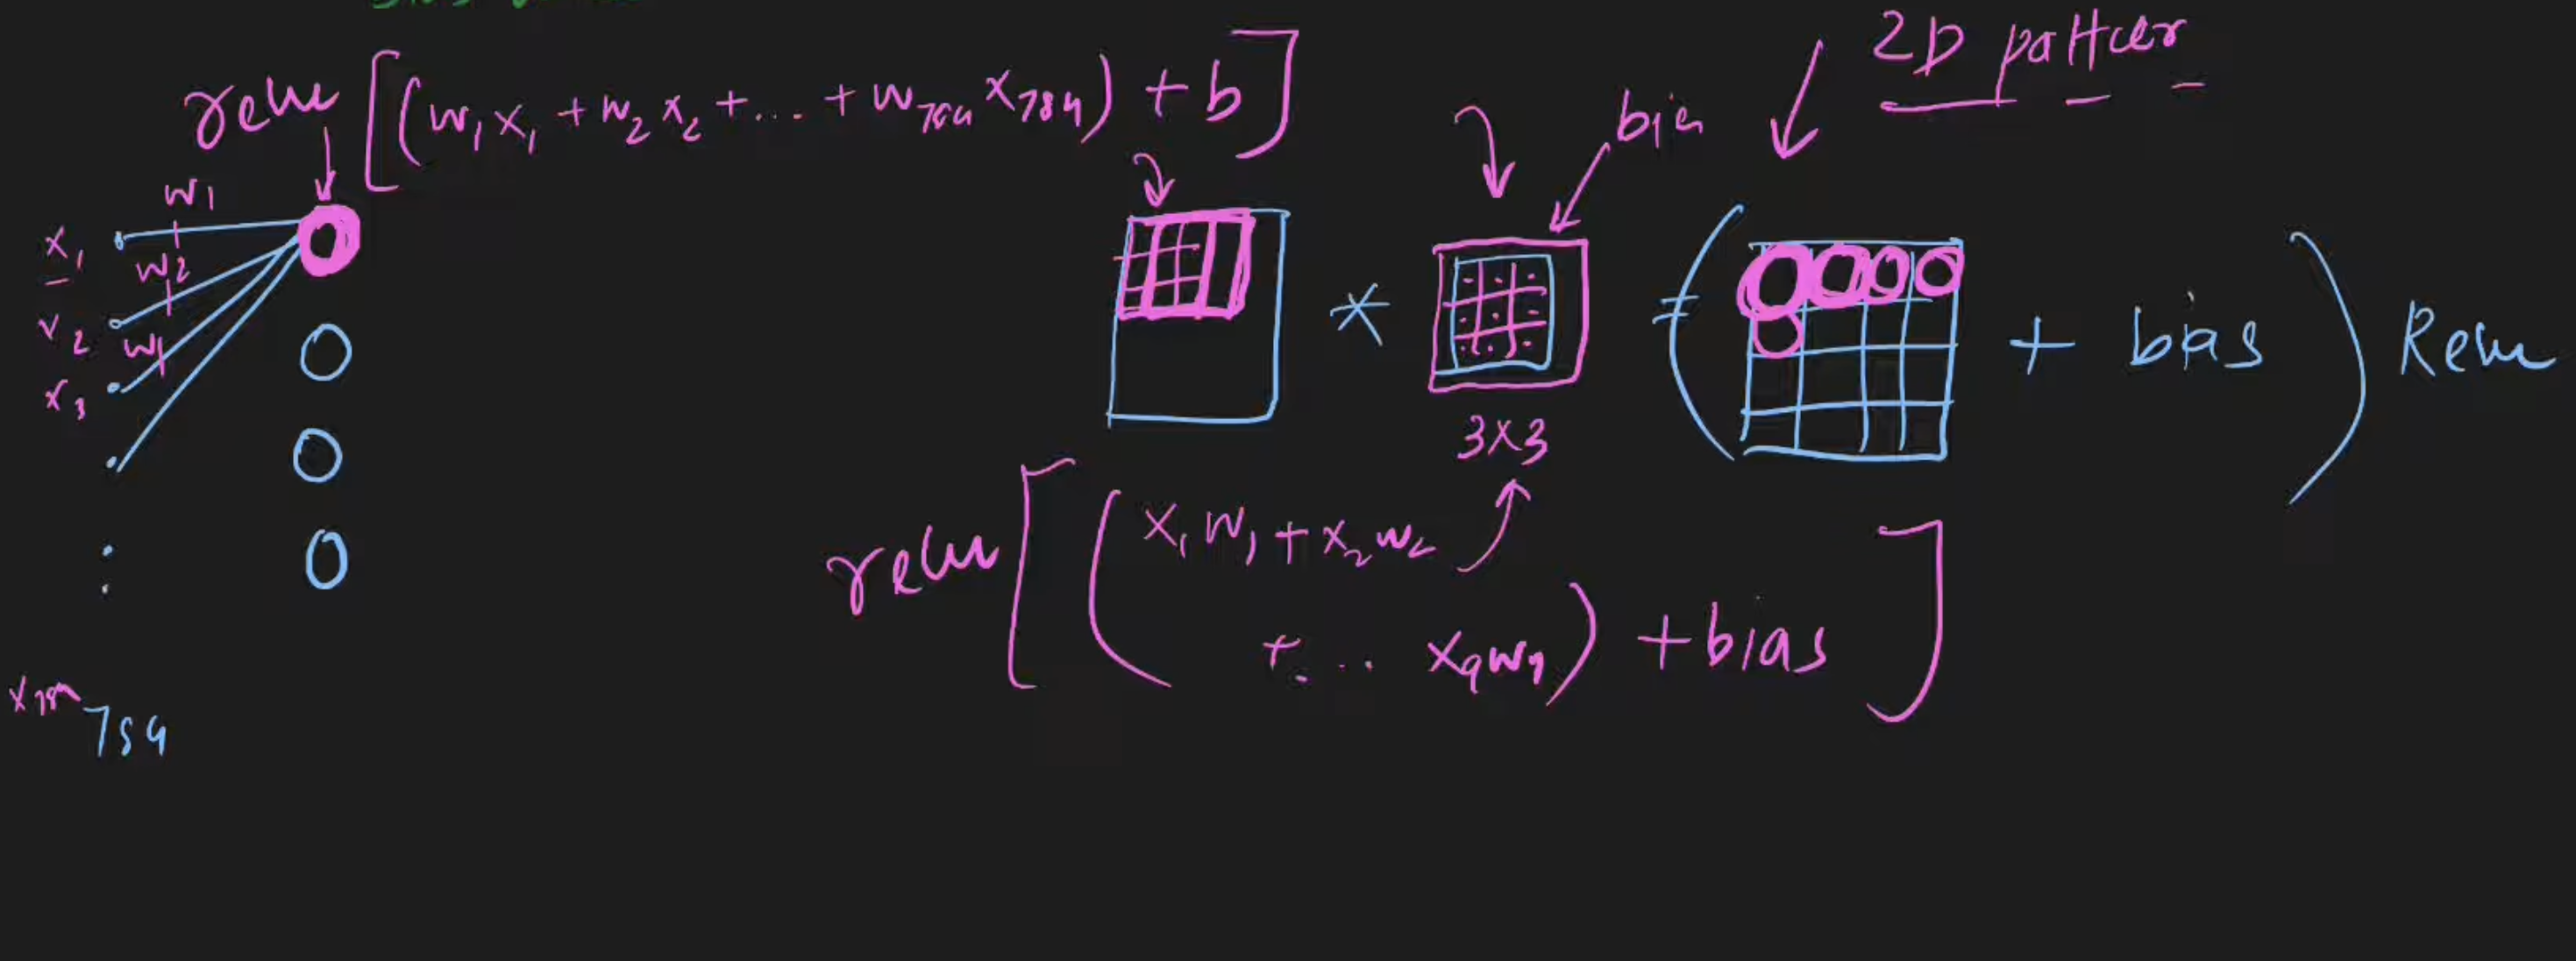
---

### 5. Interview/Exam Questions

**Q: Why can't we just use a standard ANN for image classification?**

**A:** Three reasons:
1. **Computational cost** – too many parameters
2. **Overfitting** – too many parameters relative to training data
3. **Loss of spatial structure** – ANN doesn't capture that nearby pixels form meaningful patterns

**Q: What is the fundamental similarity between CNN and ANN?**

**A:** Both perform:
- Dot product of inputs with weights
- Add a bias term
- Pass through an activation function

The **difference** is *how* they receive input (window vs. entire vector) and *how* they share weights.

---

### 6. Revision Notes (Quick Recap)

- **ANN on images** → flatten → fully connected → too many parameters → bad
- **CNN on images** → sliding filter → parameter sharing → fewer parameters → good
- **Three problems with ANN**: Cost, Overfitting, Spatial arrangement
- **Core similarity**: Both use `weight × input + bias` followed by activation
- **Core difference**: CNN uses **local connectivity + parameter sharing**

---



# Topic 2: Core Similarity Between CNN and ANN

---

## 1. Introduction

**What it is:**
Before understanding the differences, it's crucial to recognize that CNNs and ANNs are **not completely different animals**. They share the same fundamental mathematical operation at their core. 

**Why it's important:**
Understanding this similarity helps you:
- Realize that backpropagation works similarly for both
- Appreciate that CNN is an *evolution* of ANN, not a replacement
- Transfer your understanding of ANN basics directly to CNN

**Real-life analogy:**
Think of ANN and CNN like a **manual transmission car vs. an automatic transmission car**. 
- Both have an engine, steering wheel, and brakes (core similarity)
- Both get you from point A to point B
- The way you shift gears is different, but the fundamental driving principles are the same

---

## 2. Detailed Explanation

### The Common Mathematical Foundation

Both CNN and ANN perform this exact sequence of operations:

```
Step 1: Multiply inputs by weights (dot product)
Step 2: Add a bias term
Step 3: Pass through an activation function (like ReLU or Sigmoid)
```

#### In ANN (Fully Connected Layer):

```
For one neuron:
Output = Activation( w₁×x₁ + w₂×x₂ + w₃×x₃ + ... + wₙ×xₙ + bias )
```

- Takes **all** input values at once
- Each neuron has its **own unique set** of weights
- No weight sharing

---

#### In CNN (Convolution Operation):

```
For one filter position:
Output = Activation( w₁×p₁ + w₂×p₂ + w₃×p₃ + ... + w₉×p₉ + bias )
```

- Takes a **local window** of input values (e.g., 3×3 patch)
- The **same filter weights** slide across the entire image
- Weight sharing happens, but the math is identical

---
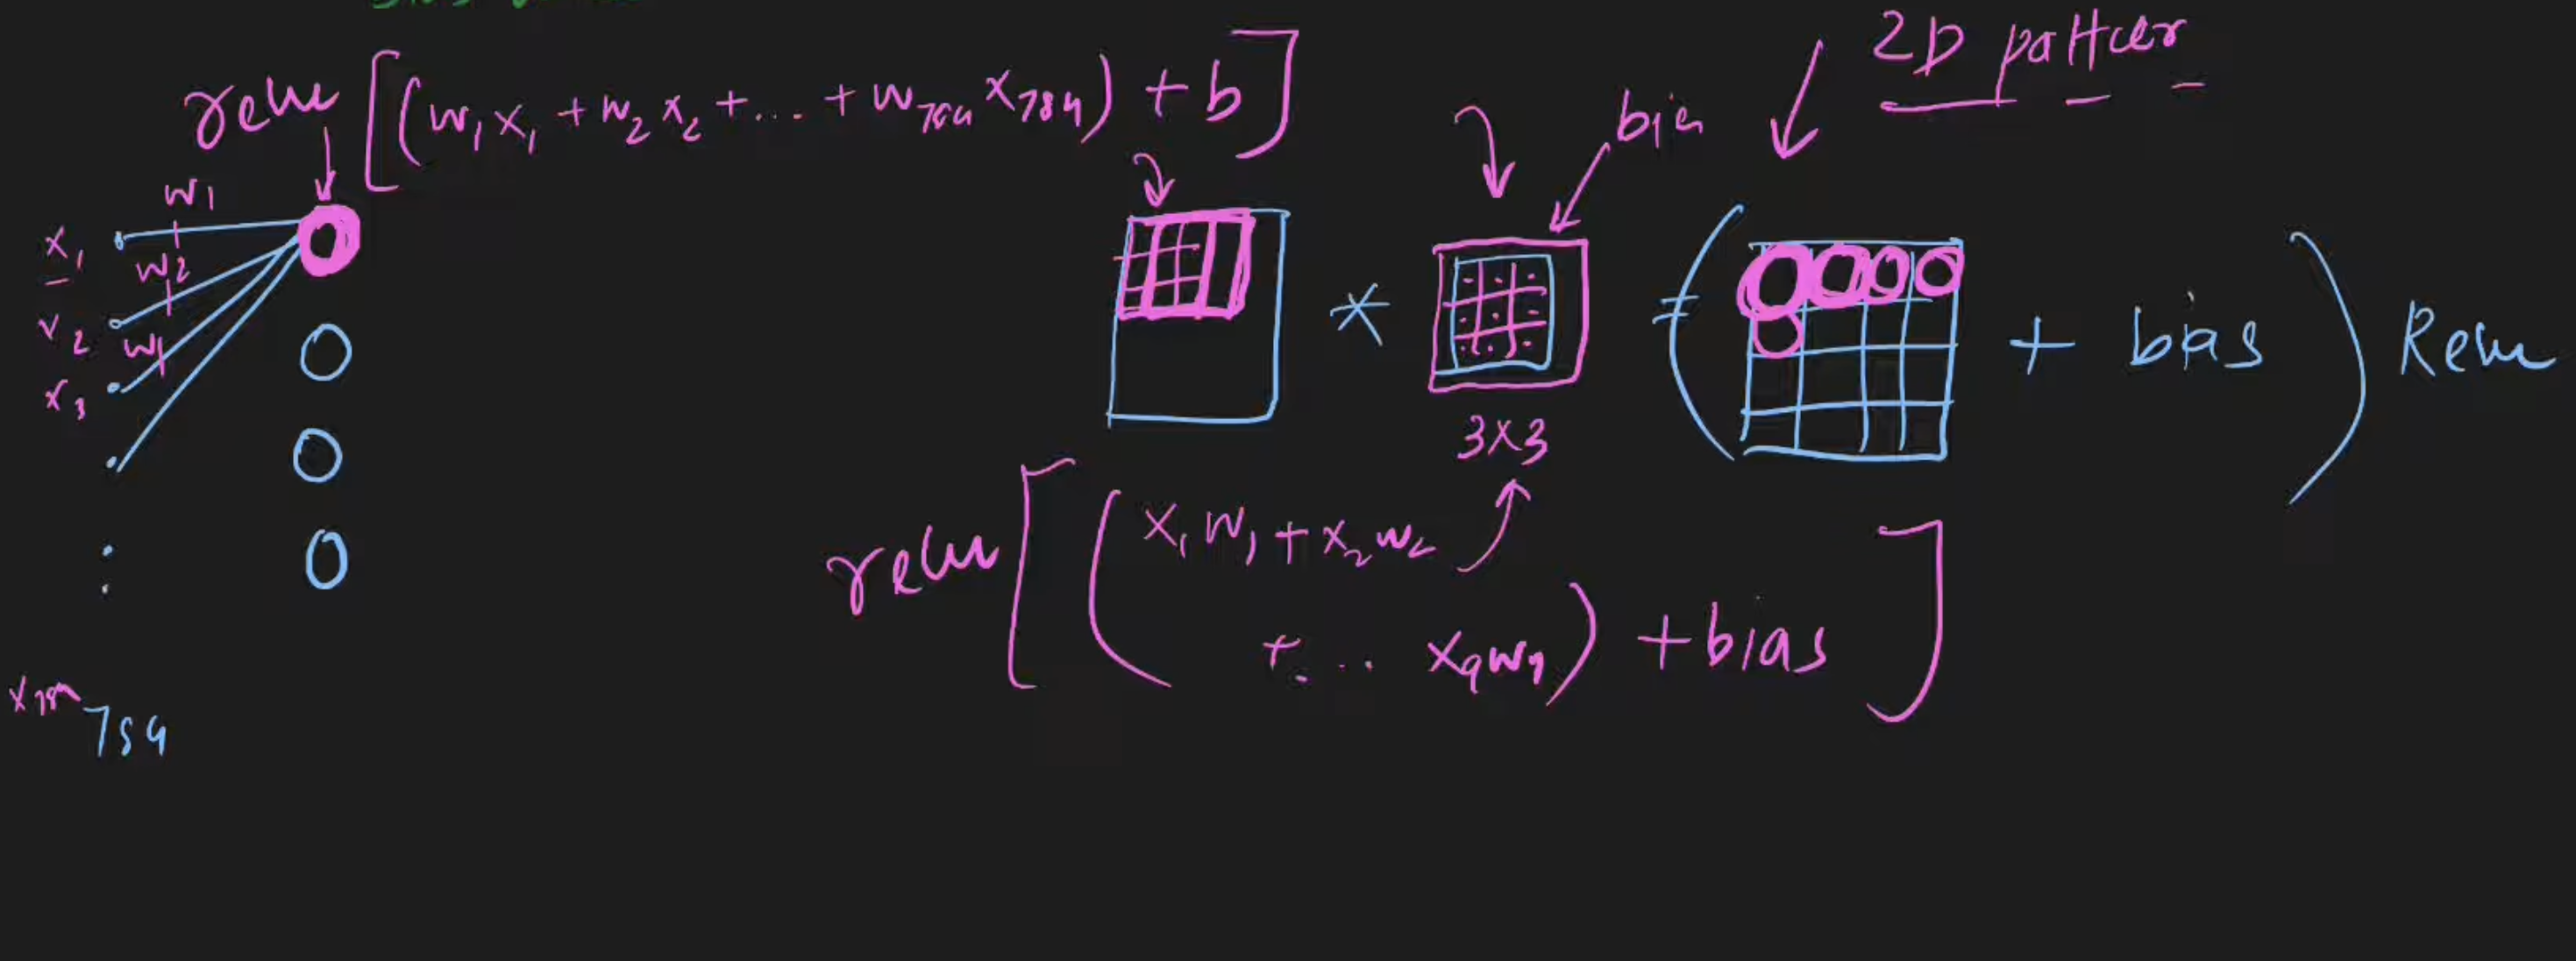

### Visual Comparison: The "Dot Product + Activation" Pattern

| Aspect | ANN | CNN |
|--------|-----|-----|
| **Input taken** | All pixels at once (flattened vector) | Local window (patch) |
| **Weight multiplication** | `w × x` for each connection | `w × pixel` for each position in filter |
| **Summation** | Sum of all `w×x` across all inputs | Sum of `w×pixel` across the filter window |
| **Bias addition** | Add bias to each neuron | Add bias to each filter |
| **Activation** | Apply activation function | Apply activation function |
| **Repeated how?** | Once per neuron | Sliding window across image |

---

### Important Insight from the Transcript

> *"Here also you do dot product and then activation function is applied. Here also you do dot product and then activation is applied. And this happens again and again, you are sliding and sliding."*

The **key similarity** is:
- ANN: Does dot product **once per neuron** (massive parallel computation)
- CNN: Does dot product **multiple times** (once per filter position) using the **same weights**

So CNN is essentially **reusing** the same set of weights many times across different locations.

---

### Why This Matters for Training

Since the core operation is identical:
- **Backpropagation** works similarly for both
- **Gradient descent** updates weights in the same way
- The **loss function** and **optimization** concepts are identical

The only difference is *how the weights are connected* to the inputs.

---

## 3. Key Points

- ✅ Both CNN and ANN use: **dot product → add bias → activation**
- ✅ CNN does this operation **repeatedly** using the **same filter weights**
- ✅ ANN does this operation **once per neuron** using **unique weights**
- ✅ The mathematical core is **identical**
- ✅ Understanding this makes learning backpropagation for CNN much easier

---

## 4. Common Mistakes

| Mistake | Correct Understanding |
|---------|----------------------|
| Thinking CNN uses a completely different math | No, it's the same `w×x + b` followed by activation |
| Believing CNN doesn't have biases | Each filter has its own bias term |
| Assuming CNN doesn't use activation functions | CNNs use ReLU, Sigmoid, etc. just like ANNs |
| Thinking CNN doesn't use dot products | The convolution operation *is* a dot product between filter and patch |

---

## 5. Interview/Exam Questions

**Q: What is the fundamental similarity between CNN and ANN?**

**A:** Both perform:
1. Weighted sum of inputs (dot product): `Σ(w × x)`
2. Add bias: `+ b`
3. Apply activation function: `f(Σ(w × x) + b)`

The difference is that ANN does this with *all inputs at once* using *unique weights*, while CNN does this with *local windows* using *shared weights*.

**Q: If CNN and ANN use the same math, why does CNN perform better on images?**

**A:** Because CNN:
- Preserves spatial structure (doesn't flatten)
- Uses parameter sharing (same filter slides everywhere)
- Has fewer parameters → less overfitting
- Is designed specifically to capture local patterns

---

## 6. Revision Notes (Quick Recap)

- **Core math is identical**: `activation(Σ(w × x) + b)`
- **ANN**: One dot product per neuron, unique weights
- **CNN**: Many dot products per filter, shared weights
- **Both use** activation functions and biases
- **Both can be trained** with backpropagation

---



# Topic 3: Key Difference – Parameter Sharing and Input Size Independence

---

## 1. Introduction

**What it is:**
The most critical difference between CNN and ANN is how they handle **parameters (weights)**. In ANN, the number of parameters depends on the **input image size**. In CNN, the number of parameters depends only on the **filter size and number of filters** – completely independent of input image dimensions.

**Why it's important:**
This is the #1 reason CNNs are used for images. It directly solves the **computational cost** and **overfitting** problems of ANN. Once you understand this, you'll know exactly why CNNs can handle massive images (like 4K resolution) while ANNs cannot.

**Real-life analogy:**
Imagine you're a teacher grading essays.
- **ANN approach**: You read every single word of every essay and give personalized feedback on each word. If the essay is longer, you have more work.
- **CNN approach**: You use a stamp with a fixed set of comments. You stamp the same comments wherever they apply, regardless of essay length. The stamp size is fixed – essay length doesn't change your workload.

---

## 2. Detailed Explanation

### How Parameters are Calculated in ANN

For a fully connected layer:

```
Total Parameters = (Input Size × Number of Neurons) + Number of Neurons (biases)
```

**Example 1:**
- Input: 28×28 = 784 pixels
- Hidden layer: 128 neurons
- Parameters = (784 × 128) + 128 = **100,352** parameters (just for one layer!)

**Example 2 (Bigger image):**
- Input: 1080×1080 = 1,166,400 pixels
- Hidden layer: 128 neurons
- Parameters = (1,166,400 × 128) + 128 ≈ **149 million** parameters!

> **Key observation:** In ANN, **parameters increase with input size**. Larger image → exponentially more parameters.

---

### How Parameters are Calculated in CNN
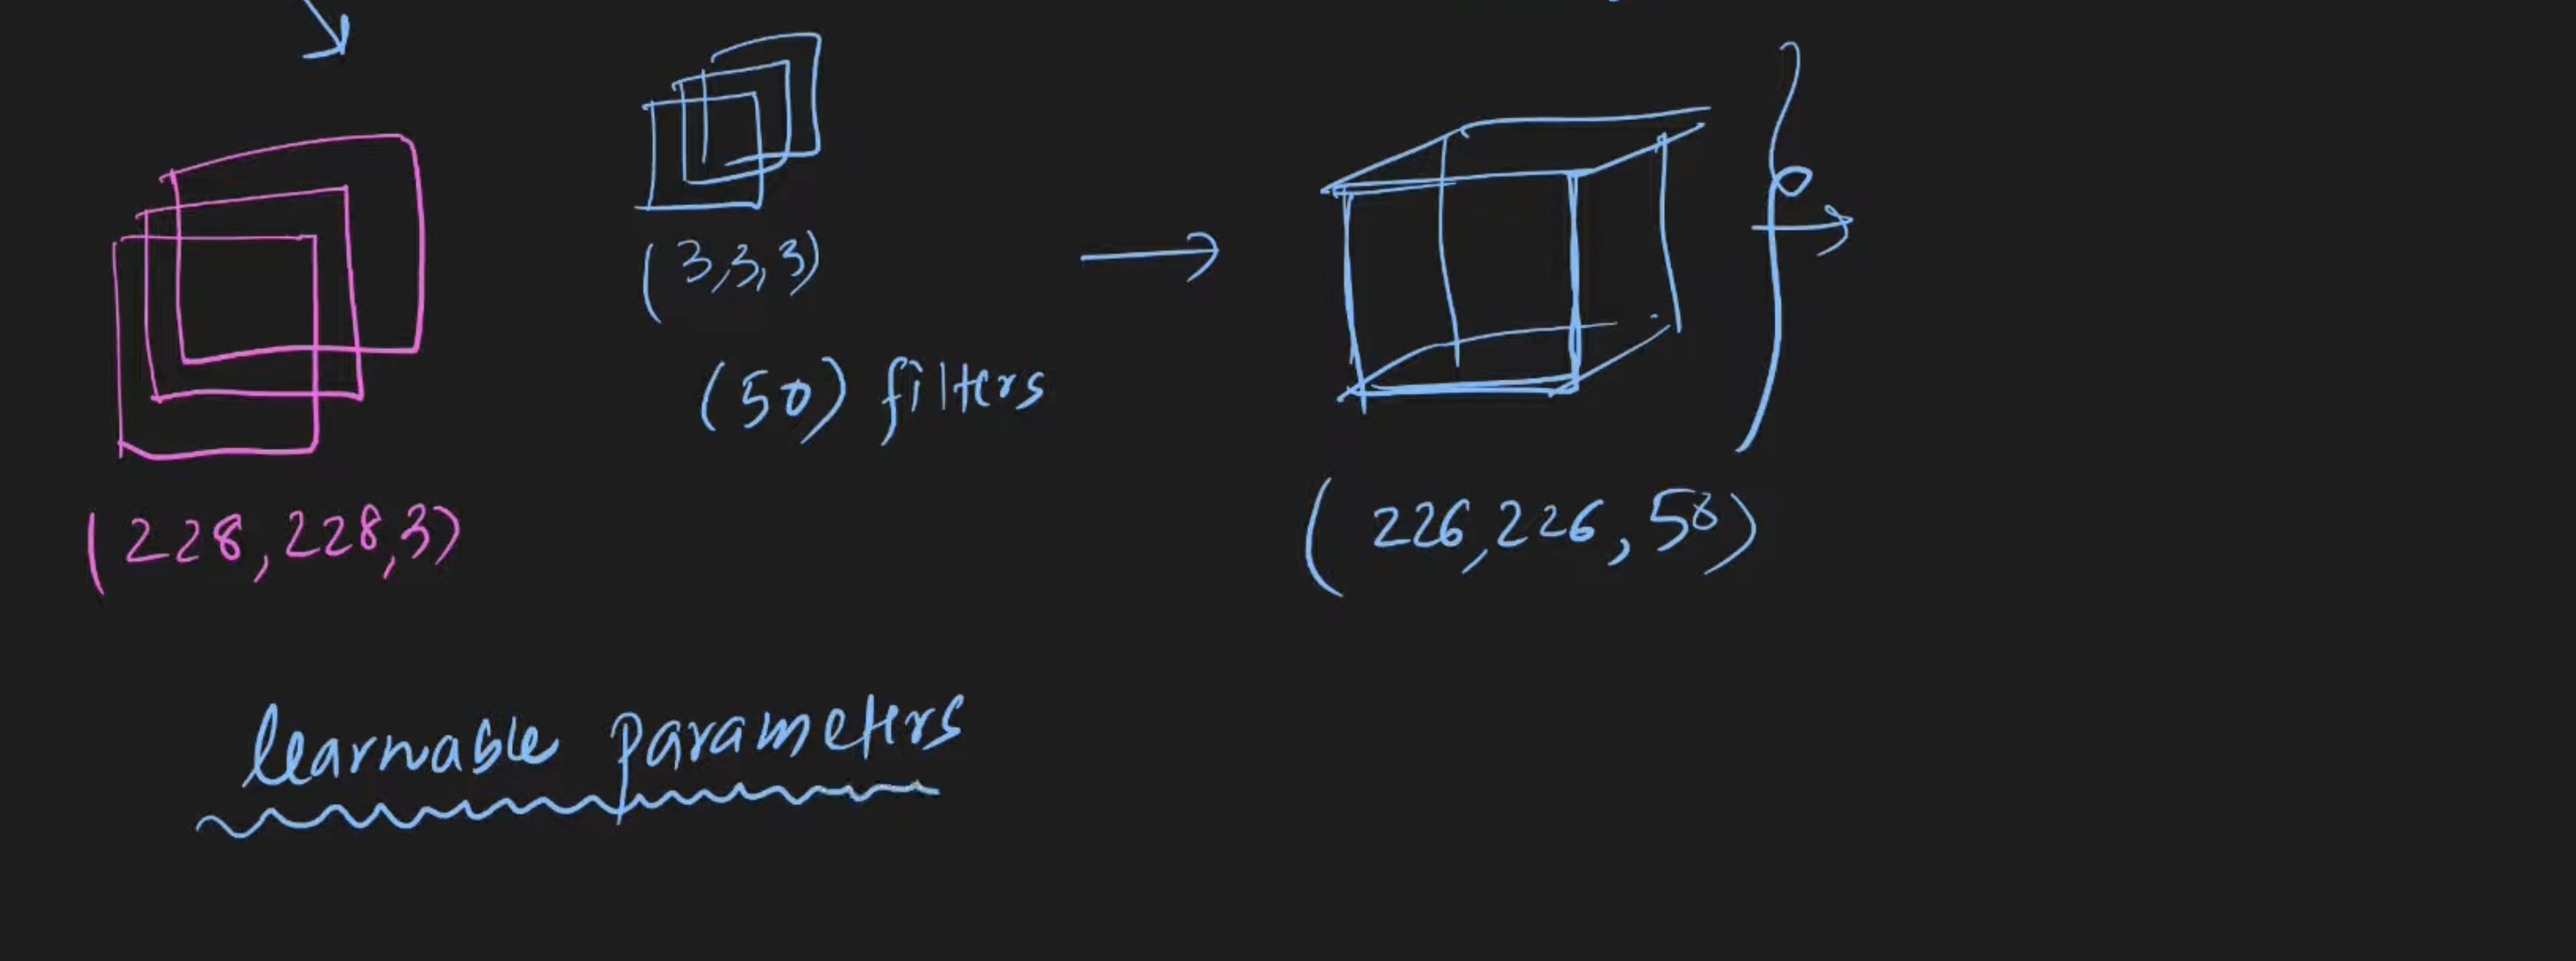
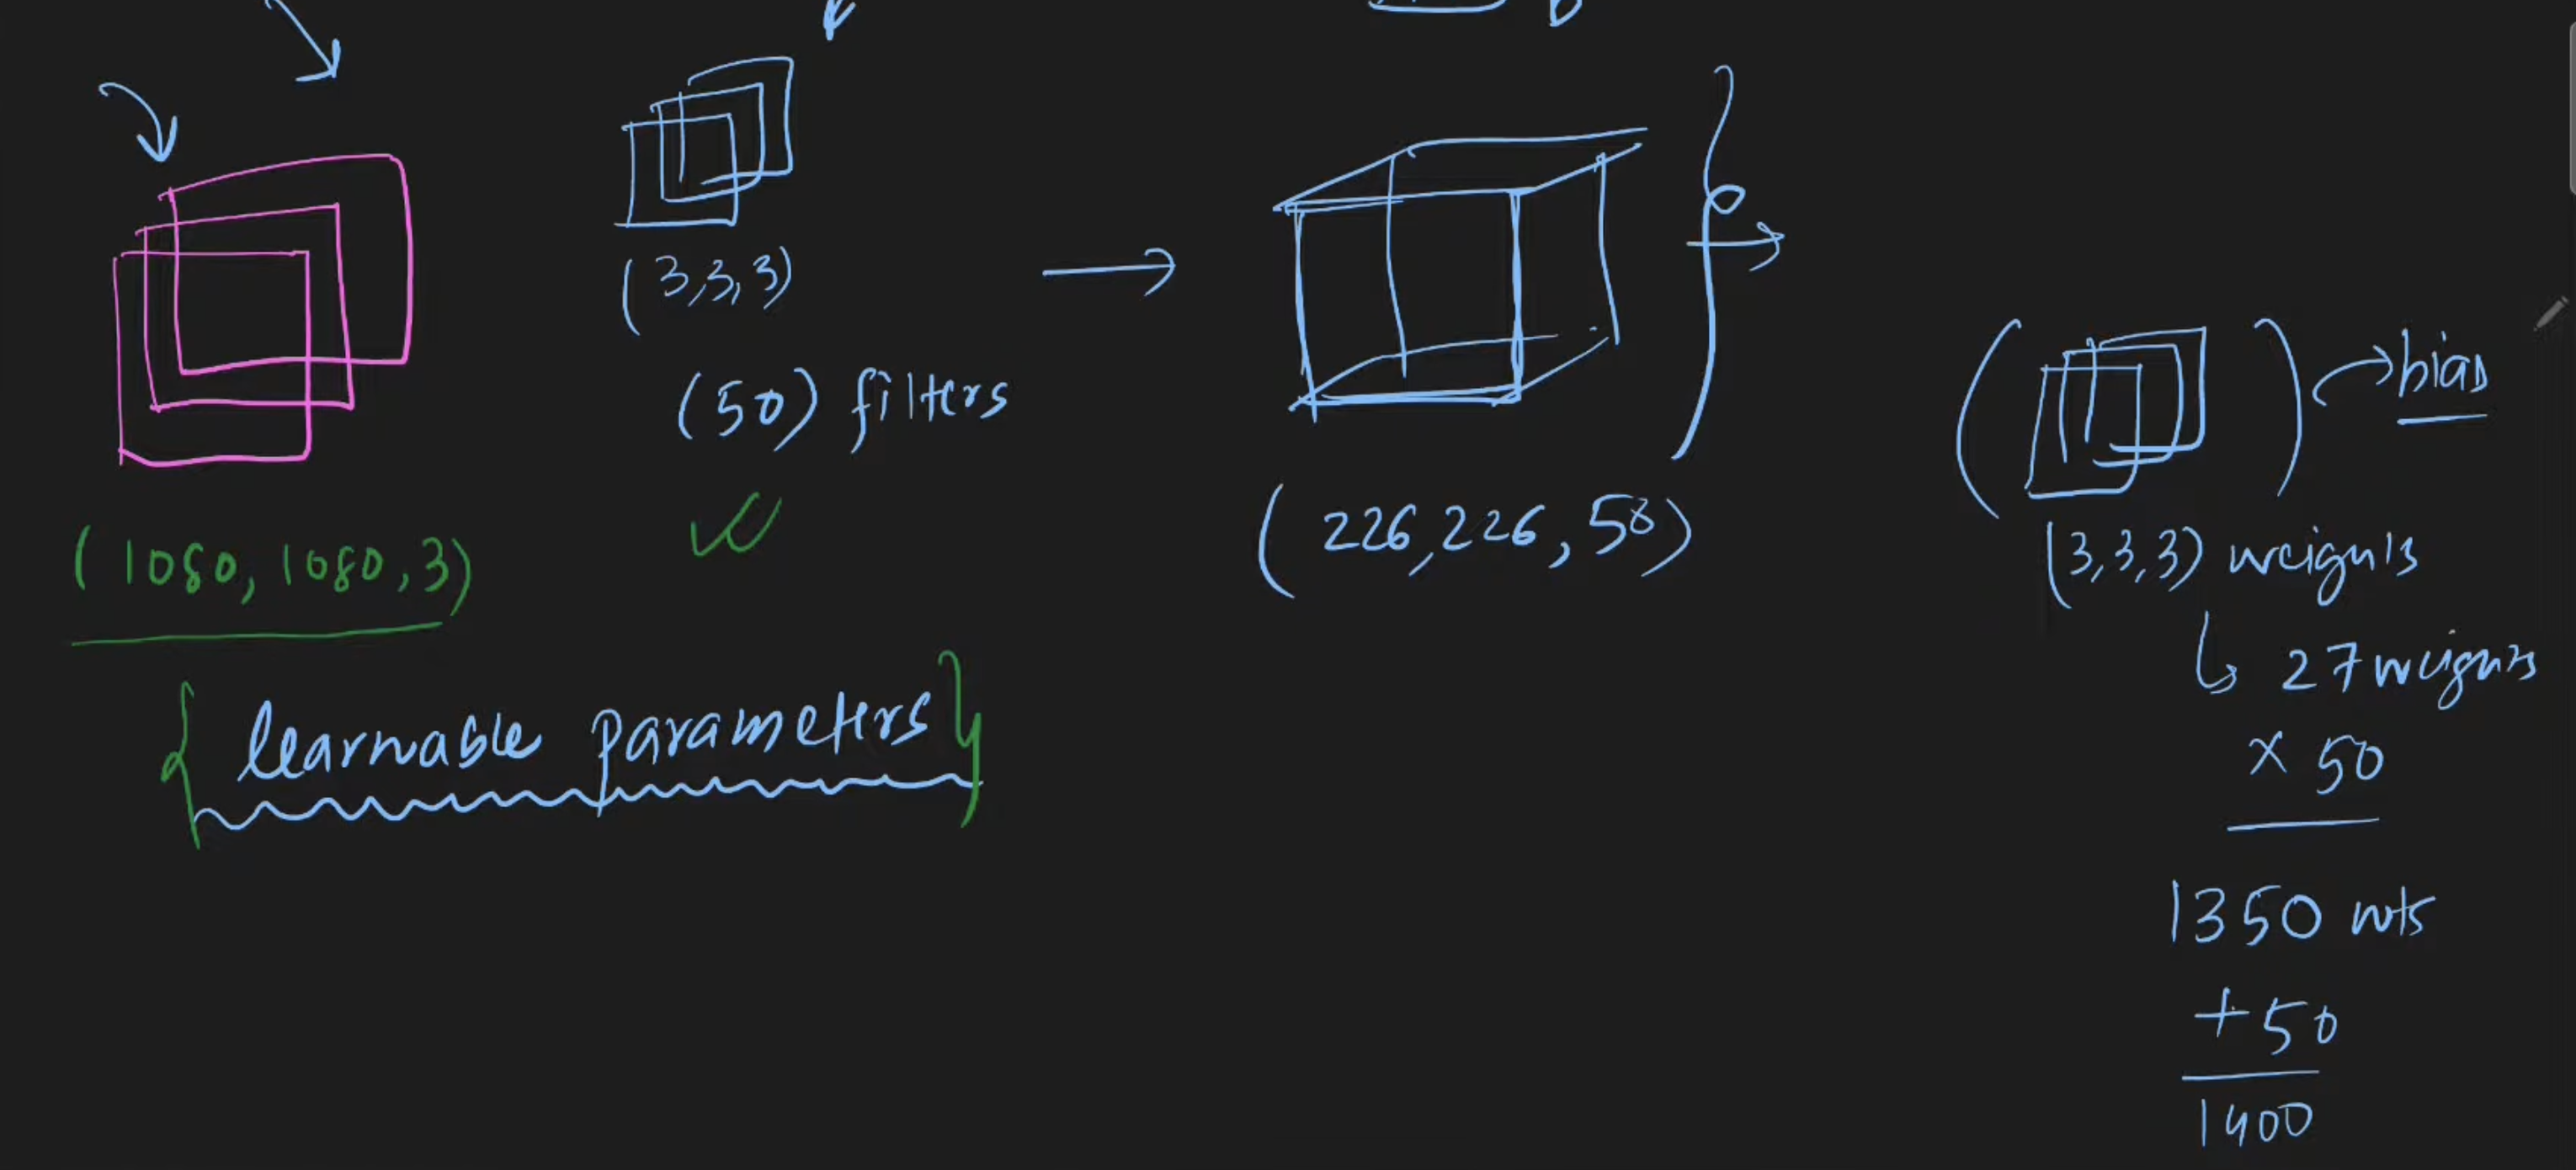
For a convolutional layer:

```
Total Parameters = (Filter Height × Filter Width × Input Channels × Number of Filters) + Number of Filters (biases)
```

**Notice:** Input image size (height and width) **does not appear** in this formula!

**Example 1 (Small image):**
- Input: 28×28×3 (RGB image)
- Filter size: 3×3
- Number of filters: 32
- Parameters = (3 × 3 × 3 × 32) + 32 = 864 + 32 = **896 parameters**

**Example 2 (Huge image):**
- Input: 1080×1080×3 (same RGB, just bigger)
- Filter size: 3×3 (same!)
- Number of filters: 32 (same!)
- Parameters = (3 × 3 × 3 × 32) + 32 = **896 parameters** (exactly the same!)

> **Key observation:** In CNN, **parameters are independent of input size**. Bigger image → same parameters!

---

### Why Does CNN Work This Way?

The secret is **parameter sharing**:

1. A filter (like 3×3) is a small pattern detector
2. This same filter **slides across the entire image**
3. The **same weights** are used at every position
4. You only need to learn the filter values once

So whether the image is 28×28 or 1080×1080:
- You still use the same 3×3 filter
- You still have the same number of weights to learn
- The filter just slides over more positions

---

### Comparison Table

| Aspect | ANN | CNN |
|--------|-----|-----|
| **Parameter dependence** | Depends on input size | Independent of input size |
| **Parameter formula** | `(input_size × neurons) + neurons` | `(filter_h × filter_w × channels × num_filters) + num_filters` |
| **28×28 image, 128 neurons/filters** | ~100,352 parameters | ~896 parameters (3×3 filter, 32 filters) |
| **1080×1080 image, 128 neurons/filters** | ~149 million parameters | ~896 parameters (same!) |
| **Scalability** | Poor – explodes with image size | Excellent – handles any image size |

---

### Worked Example from the Transcript
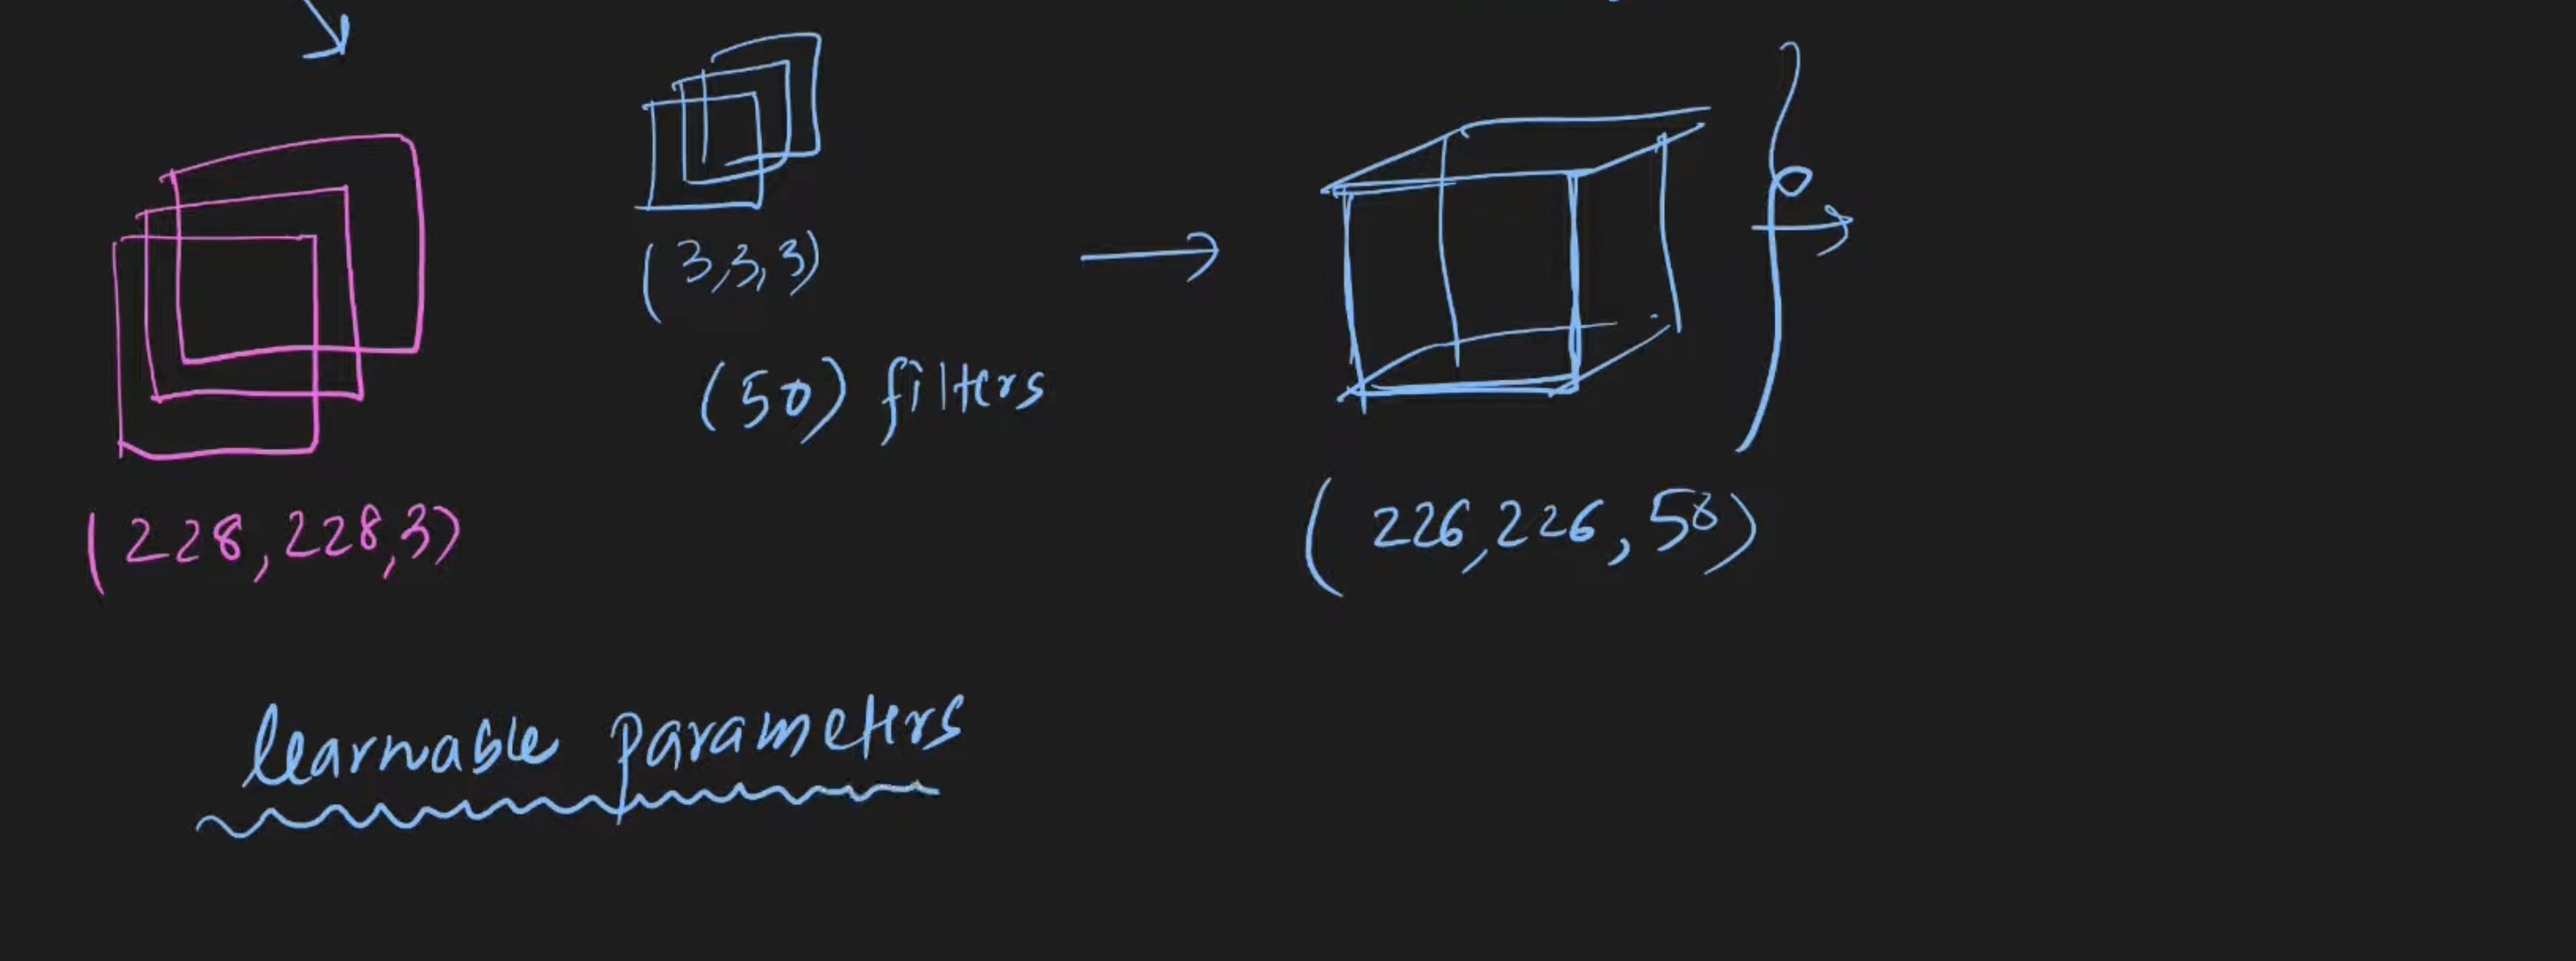
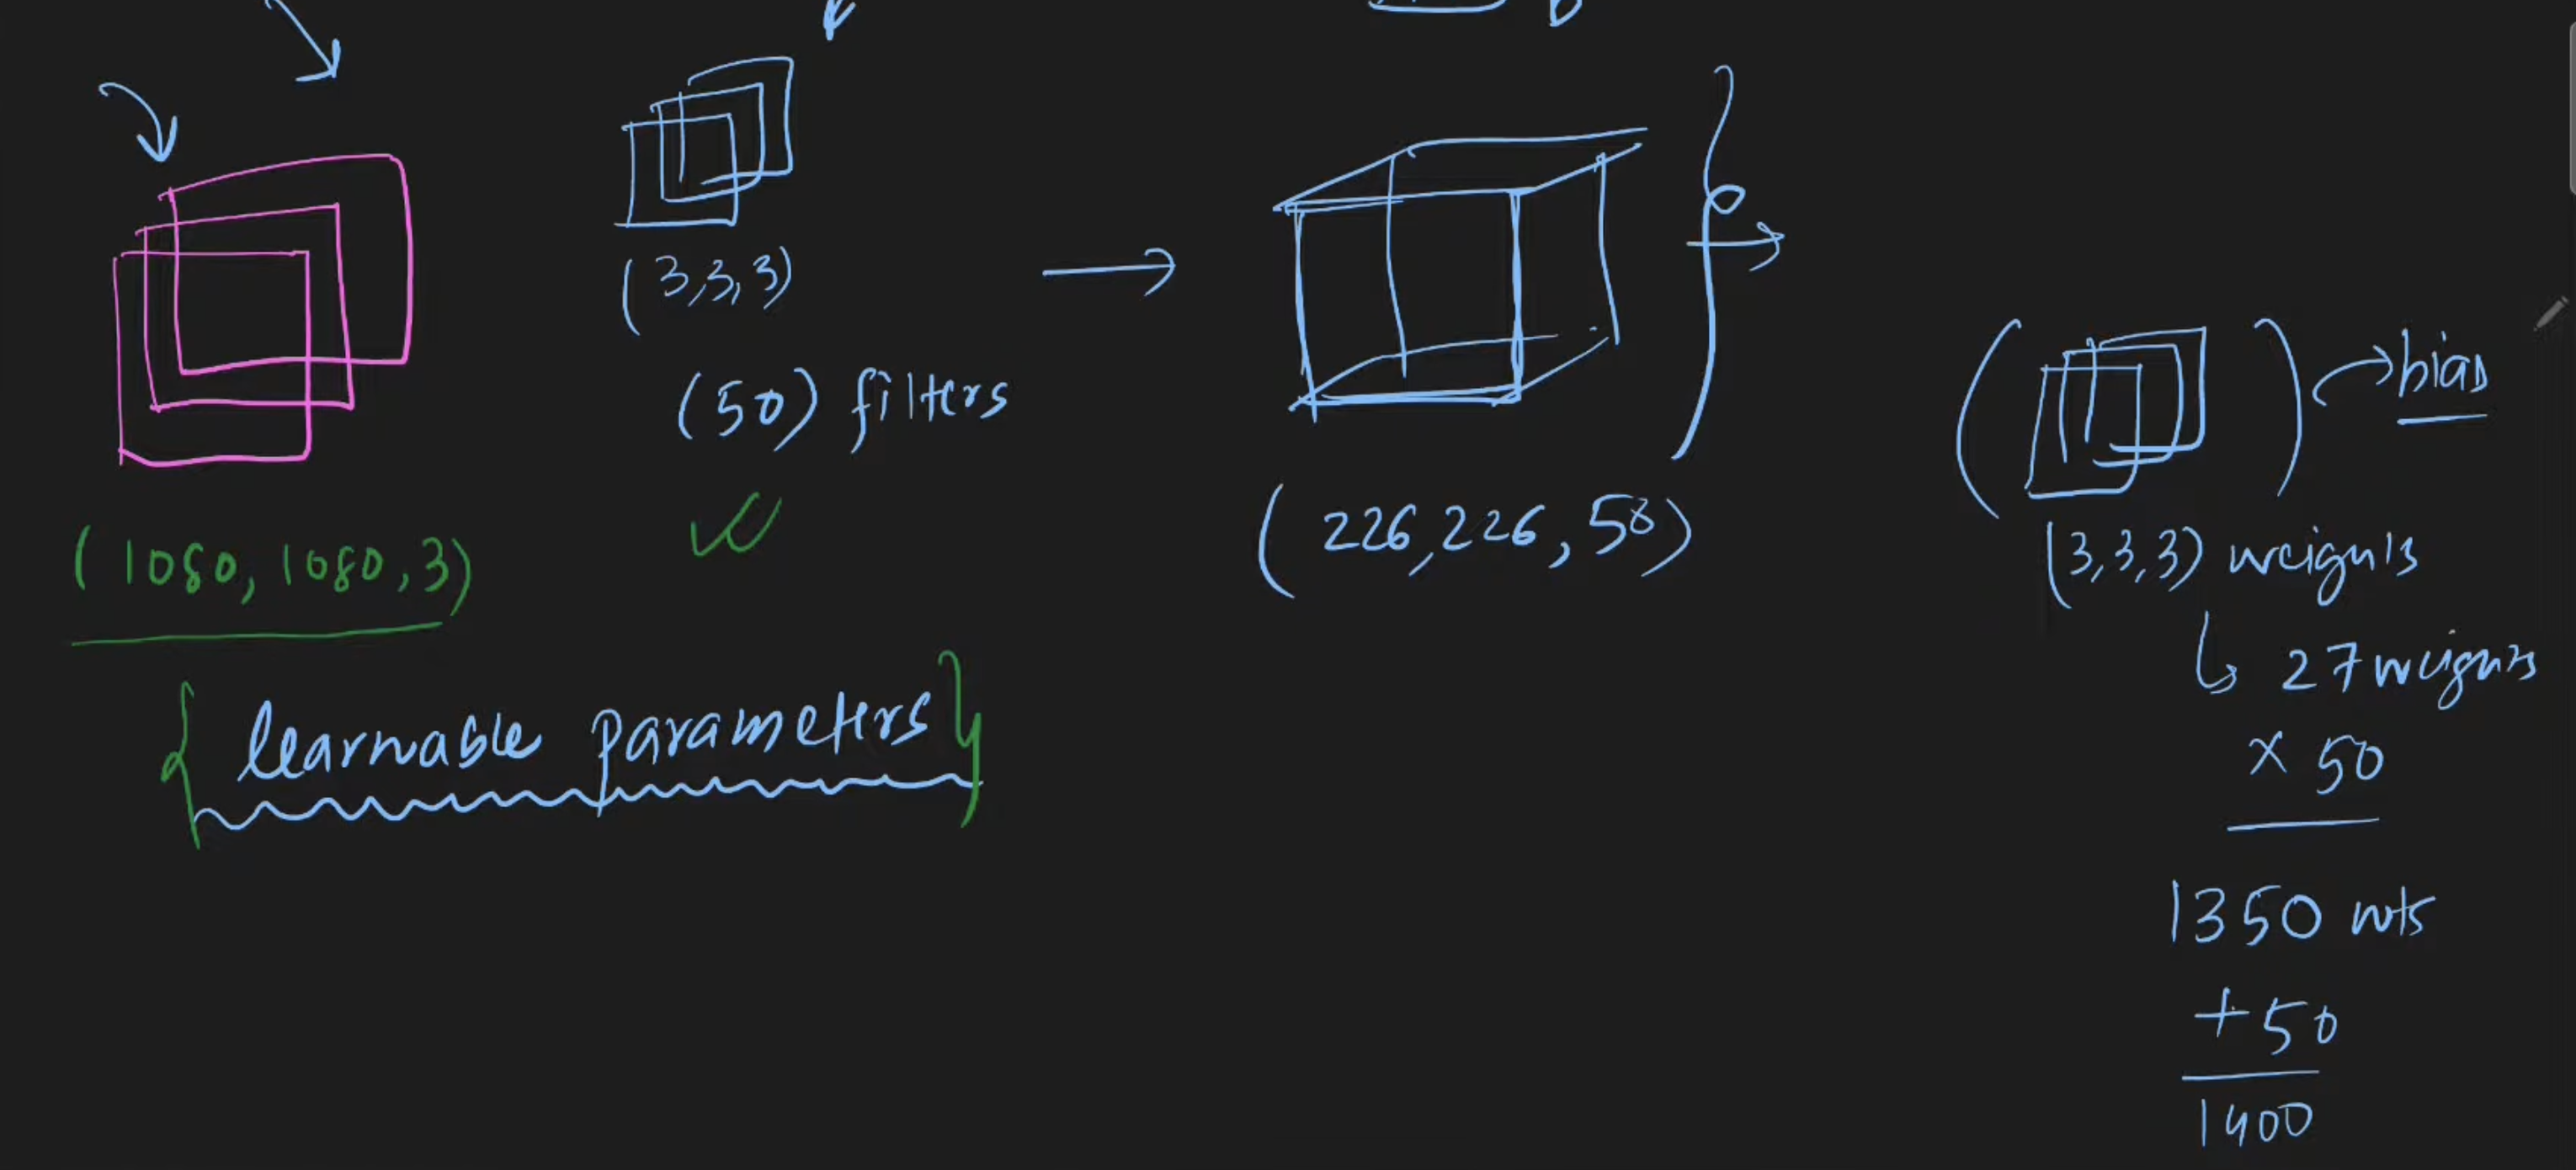](attachment:image-2.png)
The instructor asked:

> *"We have an RGB image of size 64×64×3. We use a filter of size 3×3. How many trainable parameters will we have?"*

**Solution:**

```
Parameters = (filter_h × filter_w × input_channels × num_filters) + num_filters
           = (3 × 3 × 3 × 1) + 1
           = 27 + 1
           = 28 parameters
```

Wait – but the transcript mentioned **27 + 1 = 28**, but also discussed other values. Let's clarify:

If we have **multiple filters**, say 32 filters:

```
Parameters = (3 × 3 × 3 × 32) + 32
           = 864 + 32
           = 896 parameters
```

**Key point:** The answer **does not depend** on the 64×64 image size at all!

---

### Follow-up Question from Transcript

> *"What if the image is 1080×1080 instead of 64×64? How many parameters now?"*

**Answer:** **Same!** 896 parameters (with 32 filters of size 3×3).

This is the **beauty of CNN** – it scales to any image size without increasing parameters.

---

## 3. Key Points

- ✅ ANN parameters **scale with input size** → terrible for large images
- ✅ CNN parameters **depend only on filter size and count** → independent of image size
- ✅ Parameter sharing is what makes CNN efficient
- ✅ Same filter slides everywhere → you learn one set of weights per filter
- ✅ This solves the **computational cost** and **overfitting** problems of ANN

---

## 4. Common Mistakes

| Mistake | Correct Understanding |
|---------|----------------------|
| Thinking CNN parameters depend on image size | No – they depend only on **filter size** and **number of filters** |
| Believing bigger images need bigger filters | No – you can use the same 3×3 filter on any image size |
| Forgetting to include biases in parameter count | Always add `+ num_filters` for biases |
| Thinking CNN has fewer parameters because it's "simpler" | No – it has fewer parameters because of **weight sharing**, not simplicity |

---

## 5. Interview/Exam Questions

**Q: You have a CNN with 3×3 filters and 16 filters. The input is a 256×256 RGB image. How many trainable parameters are in this convolutional layer?**

**A:**
```
Parameters = (3 × 3 × 3 × 16) + 16
           = 432 + 16
           = 448 parameters
```

The image size (256×256) is irrelevant to the parameter count.

**Q: Why doesn't CNN parameter count depend on input image size?**

**A:** Because of **parameter sharing**. The same filter weights are applied to every local region of the image. You only need to learn one set of filter values, regardless of how many positions the filter slides to.

**Q: What is the advantage of this independence from input size?**

**A:** 
1. You can train on small images and test on large images (if the model supports variable input)
2. No explosion of parameters with high-resolution images
3. Reduced overfitting due to fewer parameters
4. Memory efficient training

---

## 6. Revision Notes (Quick Recap)

- **ANN parameters**: `(input_size × neurons) + neurons` → grows with image size
- **CNN parameters**: `(filter_h × filter_w × channels × num_filters) + num_filters` → fixed!
- **CNN parameter sharing**: Same filter slides everywhere → learn weights once
- **Independence**: CNN can handle 28×28 or 1080×1080 with the same number of parameters
- **Result**: CNN solves the computational cost problem of ANN

---


# Topic 4: Comparison Summary – Computational Cost, Overfitting, and Spatial Arrangement

---

## 1. Introduction

**What it is:**
Now that we understand the parameter differences, we can connect everything back to the **three original problems** with ANN on images. This topic ties together:
1. Why ANN is computationally expensive
2. Why ANN overfits more
3. Why ANN fails to capture spatial structure – and how CNN solves all three

**Why it's important:**
This is the **complete picture**. Understanding these three differences gives you the full "why" behind using CNNs for images. It's also the most common interview question: *"Why CNN over ANN for image tasks?"*

**Real-life analogy:**
Think of ANN like reading a book by looking at one random letter at a time and trying to understand the story. CNN is like reading the book by looking at small groups of words (phrases) and understanding how they relate to each other.

---

## 2. Detailed Explanation

### The Three Problems Revisited

| Problem | ANN | CNN | Why CNN Wins |
|---------|-----|-----|--------------|
| **1. Computational Cost** | Parameters grow with image size | Parameters fixed (depends only on filter size) | CNN is efficient for large images |
| **2. Overfitting** | Too many parameters → memorizes training data | Fewer parameters → learns general patterns | CNN generalizes better |
| **3. Spatial Arrangement** | Treats pixels independently | Sliding windows capture local structure | CNN understands patterns like edges, shapes |

Let's explore each in detail.

---

### Problem 1: Computational Cost

**In ANN:**
- Every pixel connects to every neuron in the next layer
- For a 1080×1080 image (≈1.16 million pixels) and a hidden layer with 1000 neurons:
  - Parameters = 1.16M × 1000 + 1000 ≈ **1.16 billion** parameters
  - Training requires massive memory and computation
  - Often impossible with standard hardware

**In CNN:**
- Same 1080×1080 image, using 3×3 filters with 32 filters:
  - Parameters = (3×3×3×32) + 32 = **896** parameters
  - Training is fast and memory efficient
  - Can run on standard GPUs

> **The magic:** CNN parameters are **independent of image size**. The image can be huge, but the filter stays small.

---

### Problem 2: Overfitting

**What is overfitting?**
When a model learns the training data too well, including noise and irrelevant details. It performs well on training data but poorly on new, unseen data.

**In ANN:**
- With billions of parameters, the network has **too much capacity**
- It can memorize every training example
- No incentive to learn general patterns
- Test accuracy suffers significantly

**In CNN:**
- With very few parameters (hundreds or thousands), the network has **limited capacity**
- It's forced to find efficient, general patterns
- Weight sharing ensures the same pattern detector works everywhere
- Test accuracy is much better

> **Analogy:** ANN is like a student who memorizes the textbook word-for-word (fails on new questions). CNN is like a student who understands the core concepts (solves new problems easily).

---

### Problem 3: Spatial Arrangement of Pixels

**What does "spatial arrangement" mean?**
In an image, pixels that are close together form meaningful structures:
- A nose is made of a specific arrangement of nearby pixels
- An edge is a line where pixel values change sharply
- A corner is where two edges meet

**In ANN:**
- Flattens the image into a 1D vector
- Pixels that were neighbors become far apart in the vector
- The network loses information about *where* pixels are relative to each other
- It treats each pixel as an independent feature

**In CNN:**
- Preserves the 2D structure of the image
- Filters look at **local windows** (e.g., 3×3 patches)
- Each filter learns to detect a specific local pattern
- By sliding, it finds that pattern anywhere in the image
- Stacking layers detects more complex patterns (edges → shapes → objects)

> **Analogy:** ANN is like looking at a jigsaw puzzle with all pieces separated. CNN is like looking at the puzzle with small groups of connected pieces.

---

### Summary Comparison Table

| Feature | ANN | CNN |
|---------|-----|-----|
| **Input representation** | Flattened 1D vector | 2D/3D spatial structure preserved |
| **Connectivity** | Fully connected (all-to-all) | Local connectivity (small windows) |
| **Parameter sharing** | No – each connection has unique weight | Yes – same filter shared across image |
| **Parameter count** | Depends on input size | Depends on filter size & count |
| **Computational cost** | Very high for large images | Low and fixed |
| **Overfitting risk** | High (too many parameters) | Low (few parameters) |
| **Captures spatial structure** | No – treats pixels independently | Yes – sliding windows capture local patterns |
| **Best for** | Tabular data, small fixed-size inputs | Images, video, spatial data |

---

### How CNN Captures "Important Features"

The instructor mentioned that CNN automatically captures the **special arrangement of pieces**:

1. **Low-level features** (first layers): Detect edges, corners, colors
2. **Mid-level features** (middle layers): Detect shapes, textures, patterns
3. **High-level features** (later layers): Detect objects, faces, scenes

ANN has no mechanism to do this because it loses spatial structure from the start.

---

## 3. Key Points

- ✅ **Problem 1 solved:** CNN parameters are independent of input size → low computational cost
- ✅ **Problem 2 solved:** Fewer parameters → less overfitting → better generalization
- ✅ **Problem 3 solved:** Sliding filters preserve spatial arrangement → captures local patterns
- ✅ CNN uses **local connectivity + parameter sharing** to achieve all three
- ✅ ANN fails on all three counts when applied to images

---

## 4. Common Mistakes

| Mistake | Correct Understanding |
|---------|----------------------|
| Thinking CNN is always better than ANN | CNN is better **for images and spatial data**. ANN is fine for tabular data |
| Believing CNN has no fully connected layers | CNN uses fully connected layers **at the end** for classification |
| Confusing number of parameters with number of operations | CNN has **fewer parameters** but may have **more operations** (due to sliding) |
| Thinking spatial arrangement only matters for RGB images | It matters for **any** data with spatial structure (grayscale, medical images, etc.) |

---

## 5. Interview/Exam Questions

**Q: What are the three main advantages of CNN over ANN for image classification?**

**A:**
1. **Computational efficiency** – parameters don't depend on input size
2. **Less overfitting** – fewer parameters due to weight sharing
3. **Preserves spatial structure** – sliding windows capture local patterns

**Q: Why does ANN overfit more than CNN on image data?**

**A:** ANN has a massive number of parameters (each pixel connects to each neuron). With so many parameters, it can memorize the training data instead of learning general patterns. CNN has far fewer parameters due to weight sharing, forcing it to learn efficient, generalizable features.

**Q: How does CNN capture spatial arrangement when ANN cannot?**

**A:** CNN uses **sliding filters** over small local windows. This preserves the spatial relationship between neighboring pixels. Stacking multiple convolutional layers allows the network to detect increasingly complex patterns (edges → shapes → objects). ANN flattens the image, destroying all spatial relationships.

---

## 6. Revision Notes (Quick Recap)

| Problem | ANN | CNN |
|---------|-----|-----|
| **Cost** | Explodes with image size | Fixed (filter size only) |
| **Overfitting** | High (billions of parameters) | Low (few hundred parameters) |
| **Spatial structure** | Lost (flattened) | Preserved (2D sliding windows) |

**The winning formula:**  
`Local connectivity + Parameter sharing = CNN efficiency`

---



# Topic 5: Practice Question – Calculating CNN Parameters

---

## 1. Introduction

**What it is:**
Now that we understand the theory, let's practice calculating the number of **trainable parameters** in a CNN layer. This is a common interview question and a great way to test your understanding of how CNNs work.

**Why it's important:**
- Helps you **design** CNN architectures (you need to know how many parameters you're adding)
- Teaches you to **debug** models (parameter mismatches are common errors)
- Tests your understanding of **filter size, channels, and bias**

**Real-life use:**
When you build a CNN in frameworks like PyTorch or TensorFlow, you'll often need to verify your layer dimensions. Being able to calculate parameters manually helps you catch mistakes.

---

## 2. Detailed Explanation

### The Parameter Formula

For a **single convolutional layer**:

```
Total Trainable Parameters = (Filter Height × Filter Width × Input Channels × Number of Filters) + Number of Filters
                                                              ↑                                  ↑
                                                          Weight parameters                 Bias parameters
```

**Breaking it down:**

| Component | Meaning | Example (3×3 filter, 32 filters, RGB input) |
|-----------|---------|---------------------------------------------|
| Filter Height | Height of the filter (kernel) | 3 |
| Filter Width | Width of the filter (kernel) | 3 |
| Input Channels | Number of channels in input image | 3 (RGB) |
| Number of Filters | How many different filters in this layer | 32 |
| Weights | `H × W × in_channels × num_filters` | 3×3×3×32 = 864 |
| Biases | One bias per filter | 32 |
| **Total** | **Weights + Biases** | **864 + 32 = 896** |

---

### Important Observation

Notice that **image height and width do NOT appear** in the formula!

This is the key insight from earlier topics – CNN parameters are **independent of input image size**.

---

### Worked Example 1 (From the Transcript)

**Question:**
> *"We have an RGB image of size 64×64×3. We use a filter of size 3×3. How many trainable parameters will we have?"*

Wait – we need to know **how many filters**. The transcript says we have **one filter** in the first part:

**Solution (1 filter):**
```
Parameters = (Filter Height × Filter Width × Input Channels × Number of Filters) + Number of Filters
           = (3 × 3 × 3 × 1) + 1
           = 27 + 1
           = 28 parameters
```

**Solution (32 filters – as discussed in the video):**
```
Parameters = (3 × 3 × 3 × 32) + 32
           = 864 + 32
           = 896 parameters
```

---

### Worked Example 2 (Image Size Change)

**Question:**
> *"What if the image is 1080×1080×3 instead of 64×64×3? Same 3×3 filter, 32 filters. How many parameters?"*

**Solution:**
```
Parameters = (3 × 3 × 3 × 32) + 32
           = 864 + 32
           = 896 parameters
```

**Answer:** **896 parameters** – exactly the same!

> **Key learning:** The image size **does not matter** for parameter count in CNN.

---

### Worked Example 3 (Different Filter Size)

**Question:**
> *"We have an RGB image. We use 5×5 filters, and we have 16 filters. How many trainable parameters?"*

**Solution:**
```
Parameters = (5 × 5 × 3 × 16) + 16
           = 75 × 16 + 16
           = 1200 + 16
           = 1216 parameters
```

---

### Worked Example 4 (Multiple Convolutional Layers)

**Question:**
> *"Layer 1: 3×3 filters, 32 filters, RGB input (3 channels)*  
> *Layer 2: 3×3 filters, 64 filters, input from Layer 1 (32 channels)*  
> *Calculate total parameters for both layers."*

**Solution:**

**Layer 1:**
```
Parameters = (3 × 3 × 3 × 32) + 32 = 864 + 32 = 896
```

**Layer 2:**
```
Parameters = (3 × 3 × 32 × 64) + 64 = 9 × 32 × 64 + 64 = 18432 + 64 = 18496
```

**Total for both layers:**
```
896 + 18496 = 19392 parameters
```

---

### Parameter Comparison Table

| Scenario | Input Size | Filter Size | Filters | Parameters |
|----------|------------|-------------|---------|------------|
| Small image, 1 filter | 64×64×3 | 3×3 | 1 | 28 |
| Small image, 32 filters | 64×64×3 | 3×3 | 32 | 896 |
| Large image, 32 filters | 1080×1080×3 | 3×3 | 32 | 896 (same!) |
| 5×5 filters, 16 filters | Any size | 5×5 | 16 | 1216 |
| 2-layer CNN | Any size | 3×3 | 32 → 64 | 19392 |

---

## 3. Key Points

- ✅ Formula: `(H × W × in_channels × num_filters) + num_filters`
- ✅ Image height and width **do not affect** parameter count
- ✅ Each filter has **one bias** (add `num_filters` at the end)
- ✅ When stacking layers, `in_channels` = previous layer's `num_filters`
- ✅ More filters → more parameters → more capacity (and more overfitting risk)

---

## 4. Common Mistakes

| Mistake | Correct Understanding |
|---------|----------------------|
| Including image size in parameter calculation | Image size **does not** affect parameters in CNN |
| Forgetting the bias term | Always add `+ num_filters` for biases |
| Using wrong input channels | For RGB: 3 channels. For subsequent layers: use previous layer's filter count |
| Thinking parameters = number of multiplications | Parameters are the **weights being learned**. Multiplications happen during forward pass (many more than parameters!) |
| Confusing filters and channels | Filters = number of kernels. Channels = depth of input. For RGB input, channels = 3 |

---

## 5. Interview/Exam Questions

**Q: You have a CNN with the following architecture:**
- Input: 224×224 RGB image
- Conv Layer 1: 3×3 filters, 32 filters
- Conv Layer 2: 5×5 filters, 64 filters

**How many trainable parameters in each layer? What is the total?**

**A:**

**Layer 1:**
```
(3 × 3 × 3 × 32) + 32 = 864 + 32 = 896
```

**Layer 2:**
```
(5 × 5 × 32 × 64) + 64 = 25 × 32 × 64 + 64 = 51200 + 64 = 51264
```

**Total:**
```
896 + 51264 = 52160 parameters
```

**Q: You increase the input image from 224×224 to 448×448. How many new parameters does the CNN need to learn?**

**A:** **Zero!** CNN parameters do not depend on input image size. The filter size and number of filters stay the same, so the parameter count remains identical.

**Q: What happens if you increase the number of filters from 32 to 64 in the first layer?**

**A:** Parameters increase from:
- Old: `(3×3×3×32) + 32 = 896`
- New: `(3×3×3×64) + 64 = 1728 + 64 = 1792`

Parameters roughly double because you have twice as many filters (and twice as many biases).

---

## 6. Revision Notes (Quick Recap)

**CNN Parameter Formula:**
```
Params = (F_h × F_w × C_in × C_out) + C_out
```
Where:
- `F_h` = filter height
- `F_w` = filter width
- `C_in` = input channels (3 for RGB, previous layer's filters for deeper layers)
- `C_out` = number of filters in this layer

**Key Rule:** Image height and width are **never** in this formula.

**Practice tip:** Always include biases (`+ C_out`) and always use the correct `C_in`.

---

> **All topics covered!** You've now completed the full set of study notes from this transcript. You should have a solid understanding of:
> 1. Why CNN is needed for images (3 problems with ANN)
> 2. The core similarity between CNN and ANN (same math)
> 3. Parameter sharing and input size independence
> 4. The three advantages of CNN (cost, overfitting, spatial structure)
> 5. How to calculate CNN parameters
